In [5]:
import pandas as pd 

In [6]:
df = pd.read_csv('ml_dataset.csv')
df.head()

,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,geo_altitude,squawk,origin_country_Algeria,...,origin_country_Ukraine,origin_country_United Arab Emirates,origin_country_United Kingdom,origin_country_United Republic of Tanzania,origin_country_United States,origin_country_Uzbekistan,origin_country_Viet Nam,origin_country_Zambia,speed_change,altitude_change
0,27.5943,40.9151,3535.68,0,155.44,83.16,-13.98,3718.56,674.0,0,...,0,0,0,0,0,0,0,0,0.00,0.00
1,2.3048,48.7157,167.64,0,70.45,61.19,-4.23,220.98,2272.0,0,...,0,0,0,0,0,0,0,0,-84.99,-3497.58
2,4.0351,46.5247,10355.58,0,230.22,330.11,-0.33,10820.40,1000.0,0,...,0,0,0,0,0,0,0,0,159.77,10599.42
3,-7.7757,32.6880,11887.20,0,237.76,212.45,-0.33,12649.20,7616.0,0,...,0,0,0,0,0,0,0,0,7.54,1828.80
4,140.1061,35.9174,2202.18,0,142.66,182.69,-2.93,2392.68,3242.0,0,...,0,0,0,0,1,0,0,0,-95.10,-10256.52


In [7]:
print(df.shape)

(7359, 112)


In [9]:
ml_features = [
"velocity",
"geo_altitude",
"vertical_rate",
"speed_change",
"altitude_change",
"true_track"
]
df = df[ml_features]

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

In [13]:
data_scaled = pd.DataFrame(data_scaled, columns=ml_features)
data_scaled

,velocity,geo_altitude,vertical_rate,speed_change,altitude_change,true_track
0,-0.200244,-0.869657,-2.718843,-0.000079,-0.000154,-1.004429
1,-1.215983,-1.662282,-0.817541,-0.726142,-0.590340,-1.217165
2,0.693473,0.739771,-0.057020,1.364824,1.788403,1.386793
3,0.783585,1.154216,-0.057020,0.064335,0.308439,0.247489
4,-0.352981,-1.170129,-0.564034,-0.812511,-1.730851,-0.040678
...,...,...,...,...,...,...
7354,0.442376,-0.299795,-2.147477,1.574894,0.956486,1.275244
7355,0.741158,0.784669,0.007332,0.213494,0.807332,1.062508
7356,0.960942,0.881373,0.007332,0.157025,0.071851,-0.440006
7357,0.999306,1.014340,0.007332,0.027344,0.098853,1.301389


In [14]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

anomaly detection

In [16]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import ParameterGrid
import numpy as np 

In [18]:
param_grid = {
"n_estimators":[100,200,300],
"max_samples":[256,512],
"contamination":[0.01,0.02,0.05]
}

In [22]:
best_model = None
best_score = -np.inf

for params in ParameterGrid(param_grid):
    model = IsolationForest(**params, random_state=42)
    pred = model.fit_predict(data_scaled)
    anomaly_ratio = np.sum(pred==-1)/len(pred)
    score = -abs(anomaly_ratio - params["contamination"])
    if score > best_score:
        best_score = score
        best_model = model
        best_params = params

In [23]:
model = best_model
model.fit(data_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",256
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [24]:
print("Best Parameters:", best_params)

Best Parameters: {'contamination': 0.05, 'max_samples': 256, 'n_estimators': 100}


In [25]:
joblib.dump(model, "anomaly_model.pkl")

['anomaly_model.pkl']

In [26]:
pred = model.predict(data_scaled)
df["anomaly"] = pred
df["anomaly"] = df["anomaly"].map({
    1:"Normal",
    -1:"Anomaly"
})

In [27]:
scores = model.decision_function(data_scaled)
df["anomaly_score"] = scores

In [28]:
df['anomaly_score'].mean()

np.float64(0.08239969585578054)

In [29]:
anomaly_ratio = (df["anomaly"]=="Anomaly").sum()/len(df)
print("Anomaly Ratio:", anomaly_ratio)

Anomaly Ratio: 0.050006794401413236


5% --> Anomalies
95% --> Normal flights

In [30]:
import matplotlib.pyplot as plt

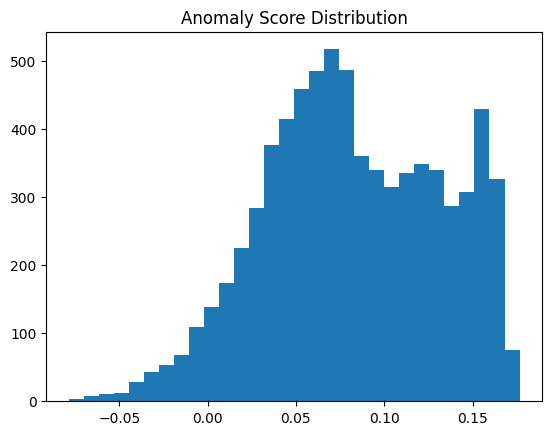

In [32]:
plt.hist(df["anomaly_score"], bins=30)
plt.title("Anomaly Score Distribution")
plt.show()

The majority of aircraft fall within the normal anomaly score range.

In [34]:
top_anomalies = df.sort_values("anomaly_score").head(10)
top_anomalies

,velocity,geo_altitude,vertical_rate,speed_change,altitude_change,true_track,anomaly,anomaly_score
5786,2.06,5783.58,-13.33,-260.36,-6057.90,36.56,Anomaly,-0.078602
2706,1.29,10683.24,-36.41,-15.47,9799.32,182.81,Anomaly,-0.078527
3716,0.00,14325.60,0.33,-40.81,14036.04,149.06,Anomaly,-0.070636
2487,2.06,21046.44,0.00,-190.58,13609.32,270.00,Anomaly,-0.069917
3338,0.00,4678.68,12.03,-244.13,-7970.52,8.44,Anomaly,-0.069152
6136,0.06,4632.96,18.86,-251.28,-8305.80,109.69,Anomaly,-0.068430
4664,5.14,10645.14,-10.40,-74.68,10584.18,320.62,Anomaly,-0.068060
419,8.75,3992.88,29.91,-229.85,-5448.30,87.19,Anomaly,-0.065584
7198,6.69,2377.44,12.68,-241.44,-10546.08,289.69,Anomaly,-0.064141
1349,5.25,19644.36,0.00,-115.10,17876.52,258.69,Anomaly,-0.063936


risk scoring

In [35]:
def calculate_risk(row):
    risk = 0
    if abs(row["vertical_rate"]) > 15:
        risk += 2
    if row["velocity"] > 300:
        risk += 2
    if abs(row["altitude_change"]) > 1000:
        risk += 2
    if row["anomaly"] == "Anomaly":
        risk += 3
    return risk

df["risk_score"] = df.apply(calculate_risk, axis=1)
df.head()

,velocity,geo_altitude,vertical_rate,speed_change,altitude_change,true_track,anomaly,anomaly_score,risk_score
0,155.44,3718.56,-13.98,0.00,0.00,83.16,Normal,0.027538,0
1,70.45,220.98,-4.23,-84.99,-3497.58,61.19,Normal,0.054164,2
2,230.22,10820.40,-0.33,159.77,10599.42,330.11,Normal,0.100323,2
3,237.76,12649.20,-0.33,7.54,1828.80,212.45,Normal,0.150055,2
4,142.66,2392.68,-2.93,-95.10,-10256.52,182.69,Normal,0.060459,2


In [38]:
def risk_level(score):
    if score >=6:
        return "HIGH"
    elif score >=3:
        return "MEDIUM"
    else:
        return "LOW"

df["risk_level"] = df["risk_score"].apply(risk_level)

In [39]:
df.columns

Index(['velocity', 'geo_altitude', 'vertical_rate', 'speed_change',
       'altitude_change', 'true_track', 'anomaly', 'anomaly_score',
       'risk_score', 'risk_level'],
      dtype='object')

In [41]:
traj_needed_data = pd.read_csv("dashboard_dataset.csv")

In [42]:
df["latitude"] = traj_needed_data["latitude"]
df["longitude"] = traj_needed_data["longitude"]
df["time_position"] = traj_needed_data["time_position"]

In [43]:
df = df.sort_values("time_position")

In [46]:
df.reset_index(drop=True)

,velocity,geo_altitude,vertical_rate,speed_change,altitude_change,true_track,anomaly,anomaly_score,risk_score,risk_level,latitude,longitude,time_position
0,162.98,3192.78,12.68,162.98,0.00,127.30,Normal,0.022023,0,LOW,55.4063,38.5946,2025-08-19 08:36:27
1,217.14,6035.04,7.80,-9.73,-5890.26,292.13,Normal,0.063561,2,LOW,55.3682,22.3816,2025-08-19 08:49:56
2,232.83,8854.44,0.00,-10.20,-5052.06,153.77,Normal,0.116150,2,LOW,26.2981,78.7344,2025-08-19 08:58:23
3,234.63,10972.80,0.00,7.55,-967.74,186.67,Normal,0.163862,0,LOW,54.4401,23.4560,2025-08-19 09:19:22
4,27.96,10012.68,-0.33,-192.14,-762.00,257.24,Normal,0.053738,0,LOW,55.9647,37.4180,2025-08-19 09:26:02
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7354,225.83,11879.58,0.00,-19.18,198.12,7.72,Normal,0.118354,0,LOW,49.2649,-6.2053,2025-08-19 10:43:59
7355,195.98,3672.84,11.38,8.64,-5989.32,54.72,Normal,0.036948,2,LOW,21.3522,106.2593,2025-08-19 10:43:59
7356,224.60,11384.28,1.63,-42.92,1272.54,192.03,Normal,0.135825,2,LOW,54.4364,10.2421,2025-08-19 10:43:59
7357,212.89,7612.38,-17.56,-18.72,-3543.30,166.87,Normal,0.043810,4,MEDIUM,50.1529,-3.2278,2025-08-19 10:43:59


In [47]:
df["next_latitude"] = df["latitude"].shift(-1)
df["next_longitude"] = df["longitude"].shift(-1)

In [48]:
df = df.dropna() # removing last row. its null;

In [67]:
trajectory_features = [
    "latitude",
    "longitude",
    "velocity",
    "true_track",
    "geo_altitude",
    "vertical_rate"
]

In [68]:
X = df[trajectory_features]
y_lat = df["next_latitude"]
y_lon = df["next_longitude"]

In [69]:
from sklearn.ensemble import RandomForestRegressor
lat_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [70]:
lat_model.fit(X, y_lat)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [71]:
lon_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
lon_model.fit(X, y_lon)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [72]:
df["pred_latitude"] = lat_model.predict(X)
df["pred_longitude"] = lon_model.predict(X)

In [73]:
from sklearn.metrics import mean_absolute_error, r2_score

In [74]:
lat_mae = mean_absolute_error(y_lat, df["pred_latitude"])
lat_r2 = r2_score(y_lat, df["pred_latitude"])
lon_mae = mean_absolute_error(y_lon, df["pred_longitude"])
lon_r2 = r2_score(y_lon, df["pred_longitude"])
print("Latitude MAE:", lat_mae)
print("Latitude R2:", lat_r2)
print("Longitude MAE:", lon_mae)
print("Longitude R2:", lon_r2)

Latitude MAE: 4.9236936239467255
Latitude R2: 0.8494216058068663
Longitude MAE: 18.627800725061157
Longitude R2: 0.8543185856221089


In [75]:
import joblib
joblib.dump(lat_model, "trajectory_lat_model.pkl")
joblib.dump(lon_model, "trajectory_lon_model.pkl")

['trajectory_lon_model.pkl']

In [76]:
df.to_csv("final_airspace_data.csv", index=False)